In [94]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
os.environ['BEARER_TOKEN_FILE'] = f"/tmp/bt_u{os.getuid()}_icarus"
import matplotlib.colors as colors


## Get the csv file of grid search parameters

In [23]:
stats = pd.read_csv("/nashome/m/micarrig/icarus/nuESpine/gridSearch/generated_medulla_tomls/params.csv")
stats

,jobid,electron_threshold,electron_softmax,primary_softmax,vertex_threshold,muon_threshold
0,0,350.0,NaN,0.95,3.5,10.0
1,1,0.0,0.8,0.95,5.0,10.0
2,2,0.0,NaN,0.80,5.0,10.0
3,3,500.0,0.6,0.80,3.5,0.0
4,4,100.0,0.9,0.90,3.0,100.0
...,...,...,...,...,...,...
8095,8095,400.0,NaN,0.80,3.0,0.0
8096,8096,350.0,0.7,0.80,3.5,100.0
8097,8097,200.0,0.6,0.99,4.0,10.0
8098,8098,500.0,0.7,0.90,5.0,100.0


In [34]:
def analyze_grid_search(filename, selected_tree='events/NuMIFull/selected', total_tree='events/NuMIFull/true_signal'):
    fin = uproot.open(f"{filename}: {selected_tree}")
    fin_all = uproot.open(f"{filename}: {total_tree}")

    cat = fin['true_category'].array(library='np')
    signal_count = np.sum(cat == 0)
    background_count = np.sum(cat != 0)

    cat_all = fin_all['true_category'].array(library='np')
    signal_count_all = np.sum(cat_all == 0)

    purity = signal_count / (signal_count + background_count)
    efficiency = signal_count / (signal_count_all)

    f1_score = 2 * (purity * efficiency) / (purity + efficiency)

    sensitivity = signal_count / np.sqrt(signal_count + background_count)

    # print(f"Signal Count: {signal_count}/{signal_count_all}")
    # print(f"Background Count: {background_count}")
    # print(f"Purity: {purity:.4f}")
    # print(f"Efficiency: {efficiency:.4f}")
    # print(f"F1 Score: {f1_score:.4f}")
    # print(f"S/sqrt(S+B): {sensitivity:.4f}")

    return {
        "signal_count": signal_count,
        "background_count": background_count,
        "signal_count_all": signal_count_all,
        "purity": purity,
        "efficiency": efficiency,
        "f1_score": f1_score,
        "sensitivity": sensitivity
    }

In [35]:
stats['signal_count'] = None
stats['background_count'] = None
stats['signal_count_all'] = None
stats['purity'] = None
stats['efficiency'] = None
stats['f1_score'] = None
stats['sensitivity'] = None

In [37]:
with open("/nashome/m/micarrig/icarus/nuESpine/gridSearch/analyze/gridSearch_output_v2.list", "r") as fout:
    for ifile, filename in enumerate(fout.readlines()):
        if ifile % 10 == 0:
            print(f"Processing file {ifile}...")
        filename = filename.strip()
        index = int(filename.split("_")[-1].split(".root")[0])
        results = analyze_grid_search(filename)
        for key, value in results.items():
            stats.loc[stats['jobid'] == index, key] = value

Processing file 0...
Processing file 10...
Processing file 20...
Processing file 30...
Processing file 40...
Processing file 50...
Processing file 60...
Processing file 70...
Processing file 80...
Processing file 90...
Processing file 100...
Processing file 110...
Processing file 120...
Processing file 130...
Processing file 140...
Processing file 150...
Processing file 160...
Processing file 170...
Processing file 180...
Processing file 190...
Processing file 200...
Processing file 210...
Processing file 220...
Processing file 230...
Processing file 240...
Processing file 250...
Processing file 260...
Processing file 270...
Processing file 280...
Processing file 290...
Processing file 300...
Processing file 310...
Processing file 320...
Processing file 330...
Processing file 340...
Processing file 350...
Processing file 360...
Processing file 370...
Processing file 380...
Processing file 390...
Processing file 400...
Processing file 410...
Processing file 420...
Processing file 430...

In [38]:
stats

,jobid,electron_threshold,electron_softmax,primary_softmax,vertex_threshold,muon_threshold,signal_count,background_count,signal_count_all,purity,efficiency,f1_score,sensitivity
0,0,350.0,NaN,0.95,3.5,10.0,240,53,331,0.819113,0.725076,0.769231,14.02095
1,1,0.0,0.8,0.95,5.0,10.0,272,62,409,0.814371,0.665037,0.732167,14.883178
2,2,0.0,NaN,0.80,5.0,10.0,314,210,409,0.599237,0.767726,0.673098,13.717154
3,3,500.0,0.6,0.80,3.5,0.0,197,36,274,0.845494,0.718978,0.77712,12.905899
4,4,100.0,0.9,0.90,3.0,100.0,226,35,403,0.8659,0.560794,0.680723,13.989049
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8095,8095,400.0,NaN,0.80,3.0,0.0,223,46,317,0.828996,0.70347,0.761092,13.59655
8096,8096,350.0,0.7,0.80,3.5,100.0,227,47,331,0.828467,0.685801,0.750413,13.713572
8097,8097,200.0,0.6,0.99,4.0,10.0,271,56,386,0.828746,0.702073,0.760168,14.986334
8098,8098,500.0,0.7,0.90,5.0,100.0,193,43,274,0.817797,0.70438,0.756863,12.56323


In [144]:
print(sorted(stats['electron_threshold'].unique())) 
print(sorted(stats['electron_softmax'].unique()))
print(sorted(stats['primary_softmax'].unique()))
print(sorted(stats['vertex_threshold'].unique()))
print(sorted(stats['muon_threshold'].unique()))


[0.0, 100.0, 200.0, 225.0, 250.0, 300.0, 350.0, 400.0, 500.0]
[nan, 0.6, 0.7, 0.8, 0.9]
[0.8, 0.9, 0.95, nan, 0.99]
[2.0, 3.0, 3.5, 5.0, nan, 4.0]
[0.0, 10.0, 25.0, 100.0, nan, 50.0]


In [49]:
stats.to_csv("/nashome/m/micarrig/icarus/nuESpine/gridSearch/analyze/grid_search_results_v2.csv")

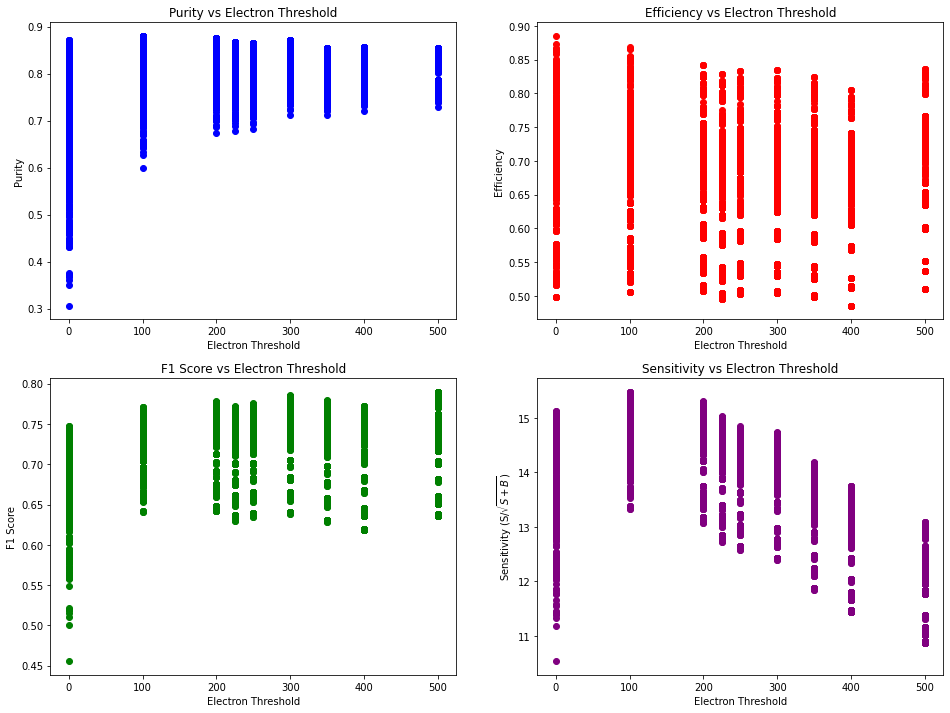

In [57]:
tuneVar = 'electron_threshold'
TuneLabel = 'Electron Threshold'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes[0, 0].scatter(stats[tuneVar], stats['purity'], color='blue')
axes[0, 0].set_xlabel(TuneLabel)
axes[0, 0].set_ylabel('Purity')
axes[0, 0].set_title('Purity vs ' + TuneLabel)

axes[0, 1].scatter(stats[tuneVar], stats['efficiency'], color='red')
axes[0, 1].set_xlabel(TuneLabel)
axes[0, 1].set_ylabel('Efficiency')
axes[0, 1].set_title('Efficiency vs ' + TuneLabel)

axes[1, 0].scatter(stats[tuneVar], stats['f1_score'], color='green')
axes[1, 0].set_xlabel(TuneLabel)
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('F1 Score vs ' + TuneLabel)

axes[1, 1].scatter(stats[tuneVar], stats['sensitivity'], color='purple')
axes[1, 1].set_xlabel(TuneLabel)
axes[1, 1].set_ylabel(r'Sensitivity (S/$\sqrt{S+B}$)')
axes[1, 1].set_title('Sensitivity vs ' + TuneLabel)
plt.show()

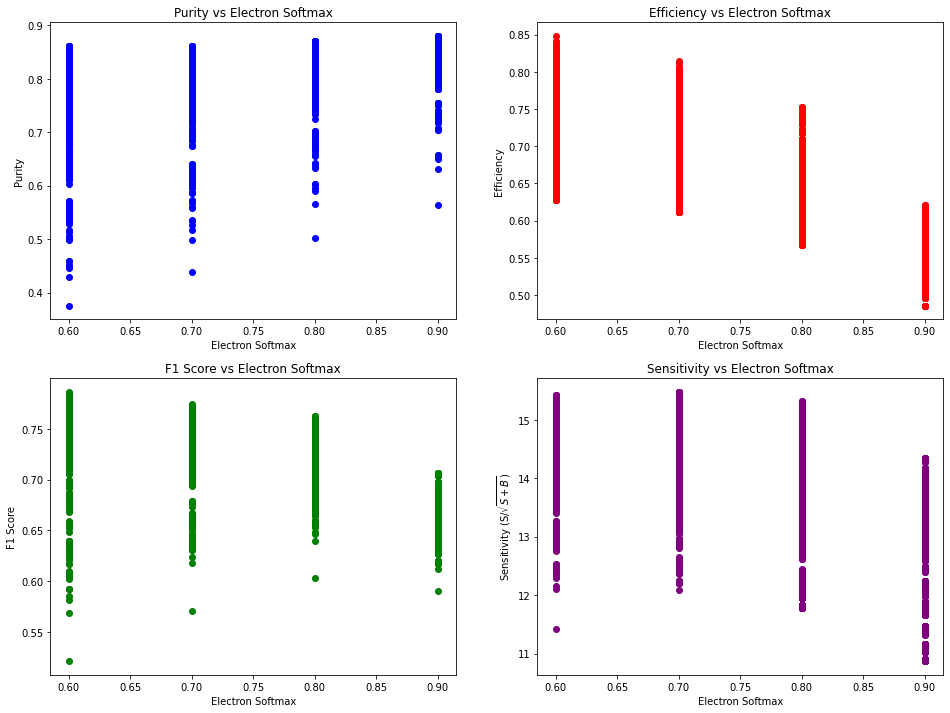

In [58]:
tuneVar = 'electron_softmax'
TuneLabel = 'Electron Softmax'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes[0, 0].scatter(stats[tuneVar], stats['purity'], color='blue')
axes[0, 0].set_xlabel(TuneLabel)
axes[0, 0].set_ylabel('Purity')
axes[0, 0].set_title('Purity vs ' + TuneLabel)

axes[0, 1].scatter(stats[tuneVar], stats['efficiency'], color='red')
axes[0, 1].set_xlabel(TuneLabel)
axes[0, 1].set_ylabel('Efficiency')
axes[0, 1].set_title('Efficiency vs ' + TuneLabel)

axes[1, 0].scatter(stats[tuneVar], stats['f1_score'], color='green')
axes[1, 0].set_xlabel(TuneLabel)
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('F1 Score vs ' + TuneLabel)

axes[1, 1].scatter(stats[tuneVar], stats['sensitivity'], color='purple')
axes[1, 1].set_xlabel(TuneLabel)
axes[1, 1].set_ylabel(r'Sensitivity (S/$\sqrt{S+B}$)')
axes[1, 1].set_title('Sensitivity vs ' + TuneLabel)
plt.show()

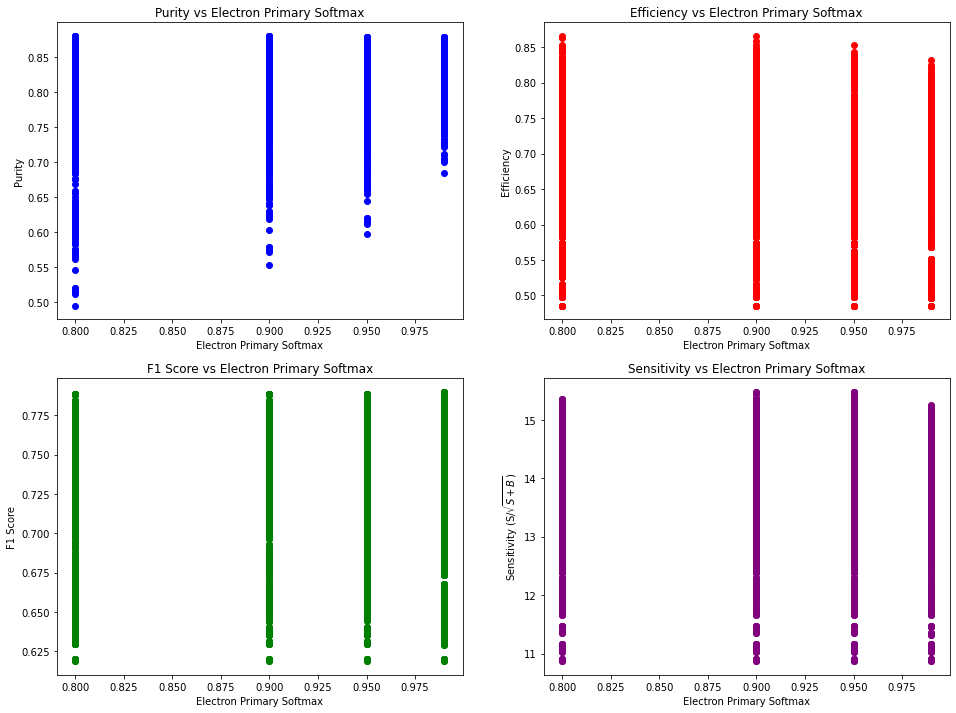

In [59]:
tuneVar = 'primary_softmax'
TuneLabel = 'Electron Primary Softmax'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes[0, 0].scatter(stats[tuneVar], stats['purity'], color='blue')
axes[0, 0].set_xlabel(TuneLabel)
axes[0, 0].set_ylabel('Purity')
axes[0, 0].set_title('Purity vs ' + TuneLabel)

axes[0, 1].scatter(stats[tuneVar], stats['efficiency'], color='red')
axes[0, 1].set_xlabel(TuneLabel)
axes[0, 1].set_ylabel('Efficiency')
axes[0, 1].set_title('Efficiency vs ' + TuneLabel)

axes[1, 0].scatter(stats[tuneVar], stats['f1_score'], color='green')
axes[1, 0].set_xlabel(TuneLabel)
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('F1 Score vs ' + TuneLabel)

axes[1, 1].scatter(stats[tuneVar], stats['sensitivity'], color='purple')
axes[1, 1].set_xlabel(TuneLabel)
axes[1, 1].set_ylabel(r'Sensitivity (S/$\sqrt{S+B}$)')
axes[1, 1].set_title('Sensitivity vs ' + TuneLabel)
plt.show()

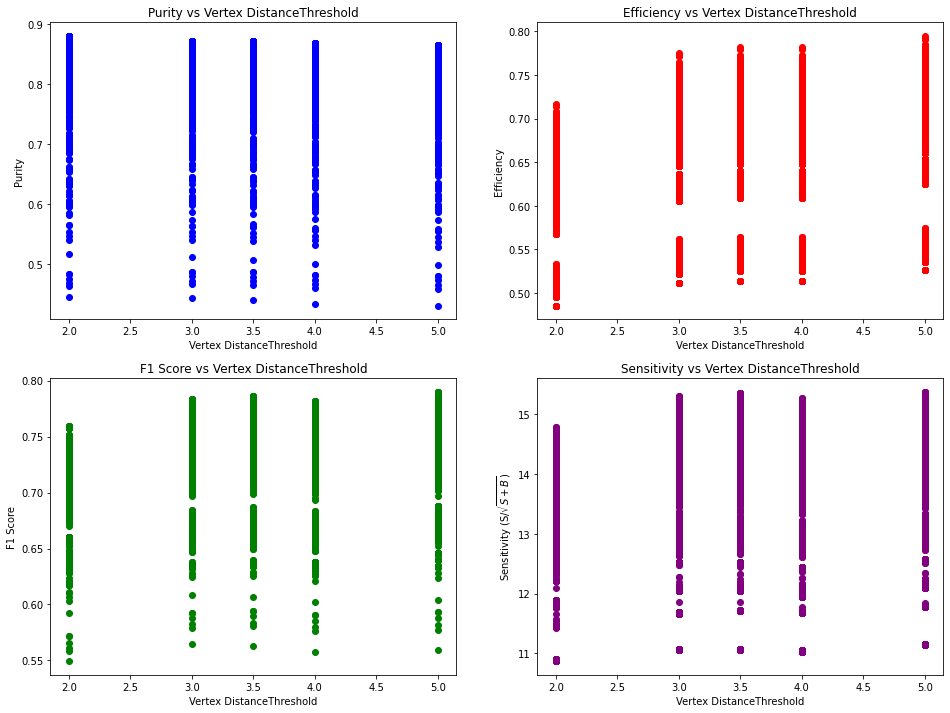

In [60]:
tuneVar = 'vertex_threshold'
TuneLabel = 'Vertex DistanceThreshold'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes[0, 0].scatter(stats[tuneVar], stats['purity'], color='blue')
axes[0, 0].set_xlabel(TuneLabel)
axes[0, 0].set_ylabel('Purity')
axes[0, 0].set_title('Purity vs ' + TuneLabel)

axes[0, 1].scatter(stats[tuneVar], stats['efficiency'], color='red')
axes[0, 1].set_xlabel(TuneLabel)
axes[0, 1].set_ylabel('Efficiency')
axes[0, 1].set_title('Efficiency vs ' + TuneLabel)

axes[1, 0].scatter(stats[tuneVar], stats['f1_score'], color='green')
axes[1, 0].set_xlabel(TuneLabel)
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('F1 Score vs ' + TuneLabel)

axes[1, 1].scatter(stats[tuneVar], stats['sensitivity'], color='purple')
axes[1, 1].set_xlabel(TuneLabel)
axes[1, 1].set_ylabel(r'Sensitivity (S/$\sqrt{S+B}$)')
axes[1, 1].set_title('Sensitivity vs ' + TuneLabel)
plt.show()

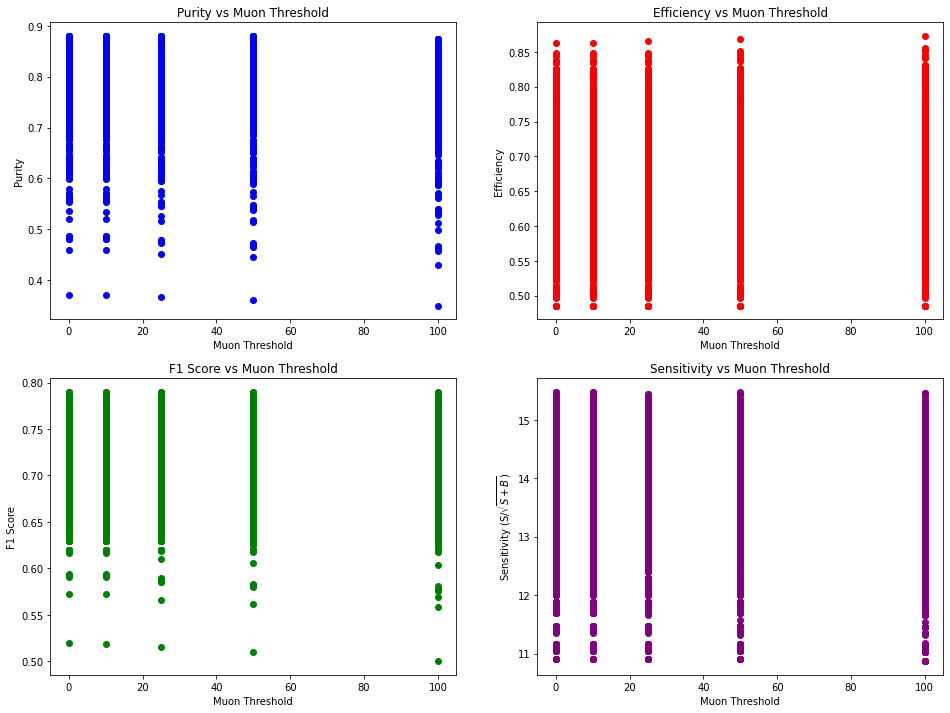

In [61]:
tuneVar = 'muon_threshold'
TuneLabel = 'Muon Threshold'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes[0, 0].scatter(stats[tuneVar], stats['purity'], color='blue')
axes[0, 0].set_xlabel(TuneLabel)
axes[0, 0].set_ylabel('Purity')
axes[0, 0].set_title('Purity vs ' + TuneLabel)

axes[0, 1].scatter(stats[tuneVar], stats['efficiency'], color='red')
axes[0, 1].set_xlabel(TuneLabel)
axes[0, 1].set_ylabel('Efficiency')
axes[0, 1].set_title('Efficiency vs ' + TuneLabel)

axes[1, 0].scatter(stats[tuneVar], stats['f1_score'], color='green')
axes[1, 0].set_xlabel(TuneLabel)
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('F1 Score vs ' + TuneLabel)

axes[1, 1].scatter(stats[tuneVar], stats['sensitivity'], color='purple')
axes[1, 1].set_xlabel(TuneLabel)
axes[1, 1].set_ylabel(r'Sensitivity (S/$\sqrt{S+B}$)')
axes[1, 1].set_title('Sensitivity vs ' + TuneLabel)
plt.show()

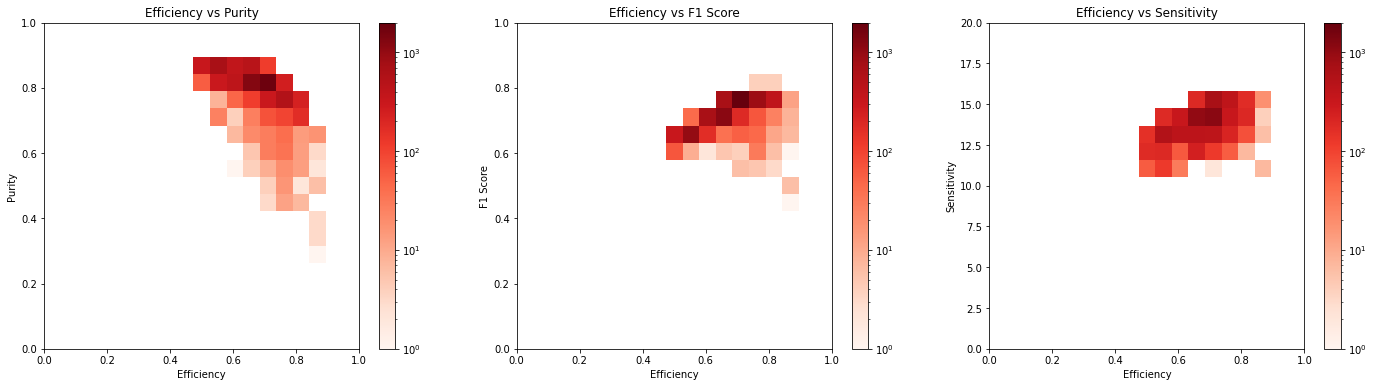

In [146]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
axes[0].hist2d(stats['efficiency'], stats['purity'], bins=np.linspace(0, 1, 20), cmap='Reds', norm=colors.LogNorm(vmin=1, vmax=2e3))
axes[0].set_xlabel('Efficiency')
axes[0].set_ylabel('Purity')
axes[0].set_title('Efficiency vs Purity')

axes[1].hist2d(stats['efficiency'], stats['f1_score'], bins=np.linspace(0, 1, 20), cmap='Reds', norm=colors.LogNorm(vmin=1, vmax=2e3))
axes[1].set_xlabel('Efficiency')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Efficiency vs F1 Score')

axes[2].hist2d(stats['efficiency'], stats['sensitivity'], bins=[np.linspace(0, 1, 20), np.linspace(0, 20, 20)], cmap='Reds', norm=colors.LogNorm(vmin=1, vmax=2e3))
axes[2].set_xlabel('Efficiency')
axes[2].set_ylabel('Sensitivity')
axes[2].set_title('Efficiency vs Sensitivity')

fig.colorbar(axes[0].collections[0], ax=axes[0])
fig.colorbar(axes[1].collections[0], ax=axes[1])
fig.colorbar(axes[2].collections[0], ax=axes[2])

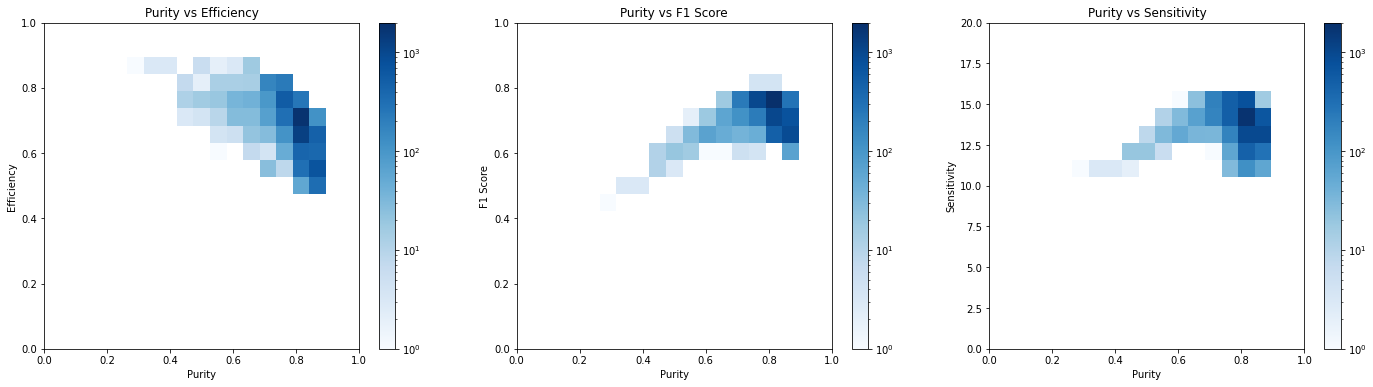

In [147]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
axes[0].hist2d(stats['purity'], stats['efficiency'], bins=np.linspace(0, 1, 20), cmap='Blues', norm=colors.LogNorm(vmin=1, vmax=2e3))
axes[0].set_xlabel('Purity')
axes[0].set_ylabel('Efficiency')
axes[0].set_title('Purity vs Efficiency')

axes[1].hist2d(stats['purity'], stats['f1_score'], bins=np.linspace(0, 1, 20), cmap='Blues', norm=colors.LogNorm(vmin=1, vmax=2e3))
axes[1].set_xlabel('Purity')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Purity vs F1 Score')

axes[2].hist2d(stats['purity'], stats['sensitivity'], bins=[np.linspace(0, 1, 20), np.linspace(0, 20, 20)], cmap='Blues', norm=colors.LogNorm(vmin=1, vmax=2e3))
axes[2].set_xlabel('Purity')
axes[2].set_ylabel('Sensitivity')
axes[2].set_title('Purity vs Sensitivity')

fig.colorbar(axes[0].collections[0], ax=axes[0])
fig.colorbar(axes[1].collections[0], ax=axes[1])
fig.colorbar(axes[2].collections[0], ax=axes[2])

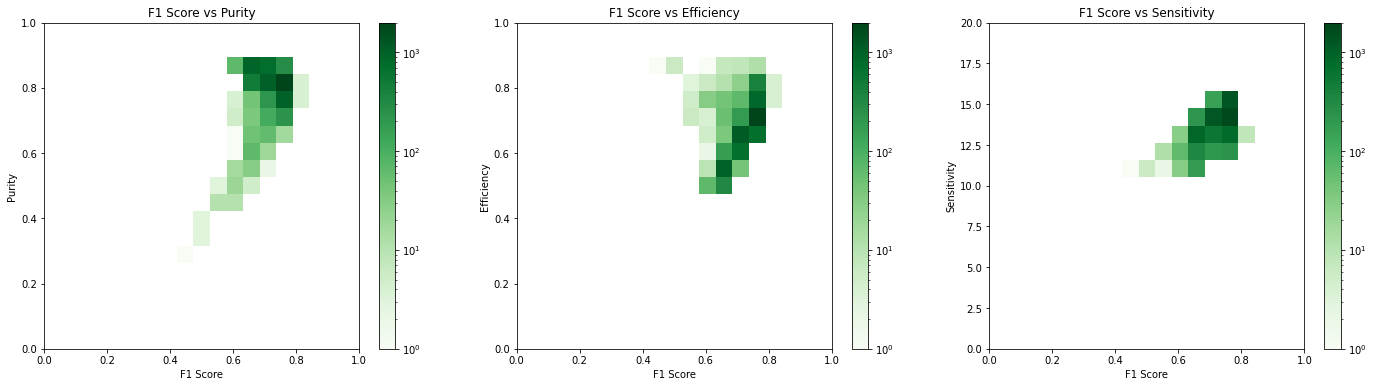

In [148]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
axes[0].hist2d(stats['f1_score'], stats['purity'], bins=np.linspace(0, 1, 20), cmap='Greens', norm=colors.LogNorm(vmin=1, vmax=2e3))
axes[0].set_xlabel('F1 Score')
axes[0].set_ylabel('Purity')
axes[0].set_title('F1 Score vs Purity')

axes[1].hist2d(stats['f1_score'], stats['efficiency'], bins=np.linspace(0, 1, 20), cmap='Greens', norm=colors.LogNorm(vmin=1, vmax=2e3))
axes[1].set_xlabel('F1 Score')
axes[1].set_ylabel('Efficiency')
axes[1].set_title('F1 Score vs Efficiency')

axes[2].hist2d(stats['f1_score'], stats['sensitivity'], bins=[np.linspace(0, 1, 20), np.linspace(0, 20, 20)], cmap='Greens', norm=colors.LogNorm(vmin=1, vmax=2e3))
axes[2].set_xlabel('F1 Score')
axes[2].set_ylabel('Sensitivity')
axes[2].set_title('F1 Score vs Sensitivity')

fig.colorbar(axes[0].collections[0], ax=axes[0])
fig.colorbar(axes[1].collections[0], ax=axes[1])
fig.colorbar(axes[2].collections[0], ax=axes[2])

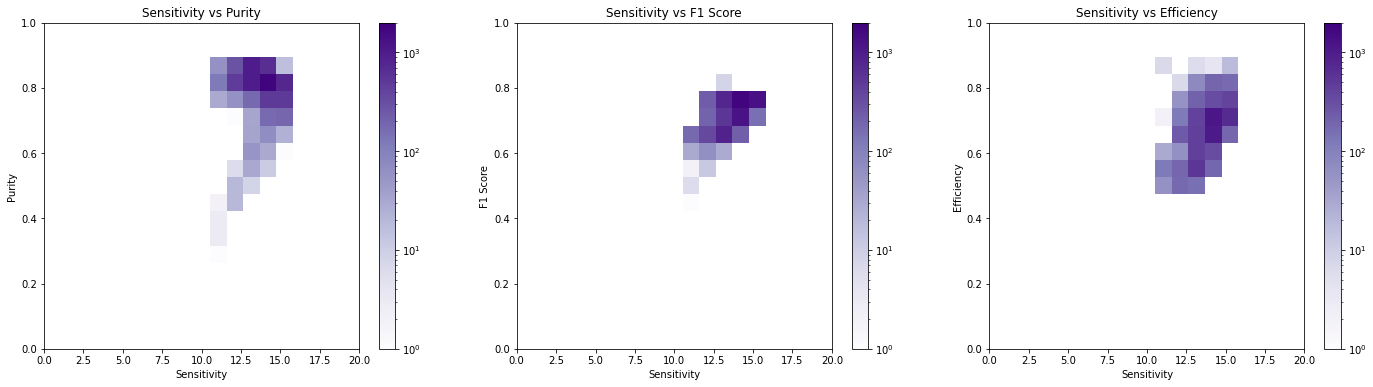

In [149]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
axes[0].hist2d(stats['sensitivity'], stats['purity'], bins=[np.linspace(0, 20, 20), np.linspace(0, 1, 20)], cmap='Purples', norm=colors.LogNorm(vmin=1, vmax=2e3))
axes[0].set_xlabel('Sensitivity')
axes[0].set_ylabel('Purity')
axes[0].set_title('Sensitivity vs Purity')

axes[1].hist2d(stats['sensitivity'], stats['f1_score'], bins=[np.linspace(0, 20, 20), np.linspace(0, 1, 20)], cmap='Purples', norm=colors.LogNorm(vmin=1, vmax=2e3))
axes[1].set_xlabel('Sensitivity')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Sensitivity vs F1 Score')

axes[2].hist2d(stats['sensitivity'], stats['efficiency'], bins=[np.linspace(0, 20, 20), np.linspace(0, 1, 20)], cmap='Purples', norm=colors.LogNorm(vmin=1, vmax=2e3))
axes[2].set_xlabel('Sensitivity')
axes[2].set_ylabel('Efficiency')
axes[2].set_title('Sensitivity vs Efficiency')

fig.colorbar(axes[0].collections[0], ax=axes[0])
fig.colorbar(axes[1].collections[0], ax=axes[1])
fig.colorbar(axes[2].collections[0], ax=axes[2])

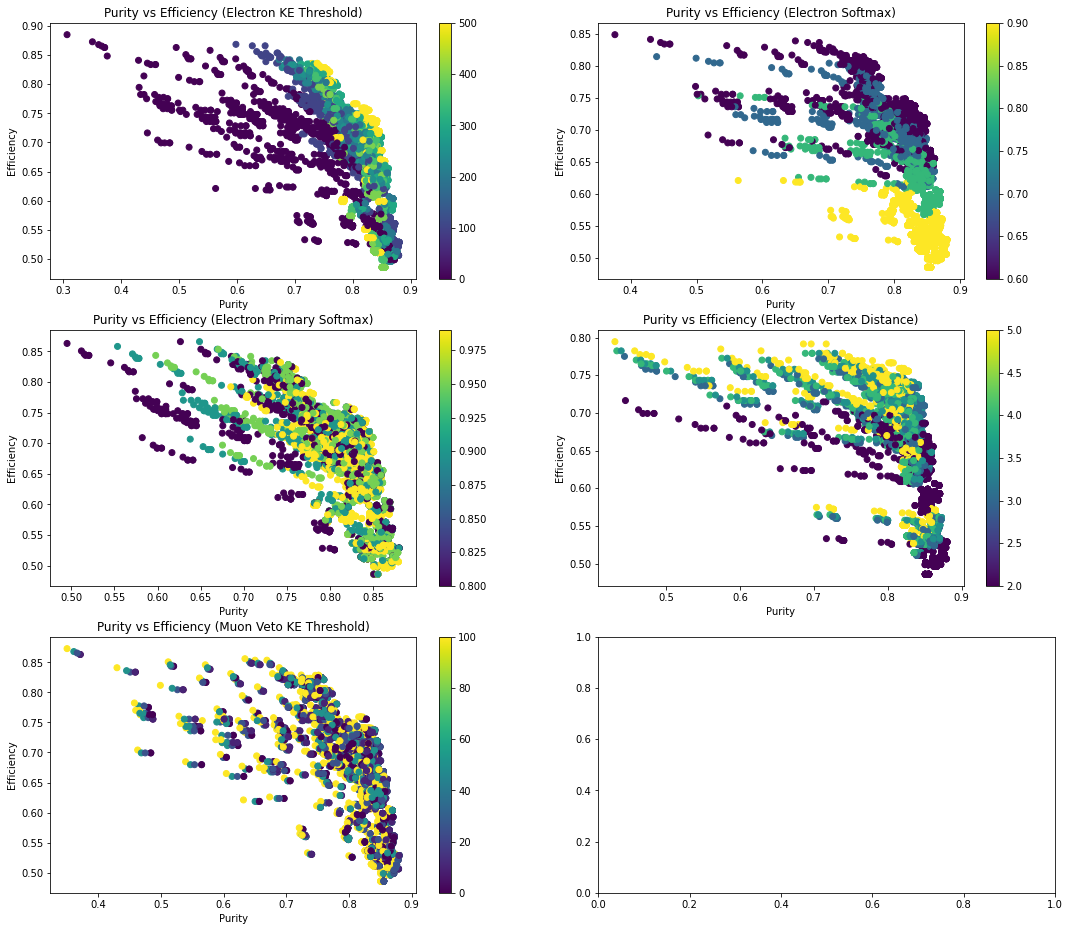

In [111]:
fig, axes = plt.subplots(3, 2, figsize=(18, 16))

axes[0, 0].scatter(stats['purity'], stats['efficiency'], c=stats['electron_threshold'], cmap='viridis')
axes[0, 0].set_xlabel('Purity')
axes[0, 0].set_ylabel('Efficiency')
axes[0, 0].set_title('Purity vs Efficiency (Electron KE Threshold)')
fig.colorbar(axes[0, 0].collections[0], ax=axes[0, 0])

axes[0, 1].scatter(stats['purity'], stats['efficiency'], c=stats['electron_softmax'], cmap='viridis')
axes[0, 1].set_xlabel('Purity')
axes[0, 1].set_ylabel('Efficiency')
axes[0, 1].set_title('Purity vs Efficiency (Electron Softmax)')
fig.colorbar(axes[0, 1].collections[0], ax=axes[0, 1])

axes[1, 0].scatter(stats['purity'], stats['efficiency'], c=stats['primary_softmax'], cmap='viridis')
axes[1, 0].set_xlabel('Purity')
axes[1, 0].set_ylabel('Efficiency')
axes[1, 0].set_title('Purity vs Efficiency (Electron Primary Softmax)')
fig.colorbar(axes[1, 0].collections[0], ax=axes[1, 0])

axes[1, 1].scatter(stats['purity'], stats['efficiency'], c=stats['vertex_threshold'], cmap='viridis')
axes[1, 1].set_xlabel('Purity')
axes[1, 1].set_ylabel('Efficiency')
axes[1, 1].set_title('Purity vs Efficiency (Electron Vertex Distance)')
fig.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])

axes[2, 0].scatter(stats['purity'], stats['efficiency'], c=stats['muon_threshold'], cmap='viridis')
axes[2, 0].set_xlabel('Purity')
axes[2, 0].set_ylabel('Efficiency')
axes[2, 0].set_title('Purity vs Efficiency (Muon Veto KE Threshold)')
fig.colorbar(axes[2, 0].collections[0], ax=axes[2, 0])


In [135]:
stats = stats.astype({'purity': 'float', 'efficiency': 'float', 'f1_score': 'float', 'sensitivity': 'float', 'signal_count': 'int', 'background_count': 'int', 'signal_count_all': 'int'})

In [136]:
stats.nlargest(10, 'efficiency')

,jobid,electron_threshold,electron_softmax,primary_softmax,vertex_threshold,muon_threshold,signal_count,background_count,signal_count_all,purity,efficiency,f1_score,sensitivity
5993,5993,0.0,NaN,NaN,NaN,NaN,362,819,409,0.306520,0.885086,0.455346,10.533765
2883,2883,0.0,NaN,NaN,NaN,100.0,357,662,409,0.350343,0.872861,0.500000,11.183587
7836,7836,100.0,NaN,NaN,NaN,NaN,350,235,403,0.598291,0.868486,0.708502,14.470719
3776,3776,0.0,NaN,NaN,NaN,50.0,355,628,409,0.361139,0.867971,0.510057,11.322742
2596,2596,100.0,NaN,0.9,NaN,NaN,349,189,403,0.648699,0.866005,0.741764,15.046458
6478,6478,100.0,NaN,0.8,NaN,NaN,349,208,403,0.626571,0.866005,0.727083,14.787605
4956,4956,0.0,NaN,NaN,NaN,25.0,354,612,409,0.366460,0.865526,0.514909,11.389763
2859,2859,0.0,NaN,NaN,NaN,0.0,353,597,409,0.371579,0.863081,0.519500,11.452832
3107,3107,0.0,NaN,NaN,NaN,10.0,353,598,409,0.371188,0.863081,0.519118,11.446809
4493,4493,0.0,NaN,0.8,NaN,NaN,353,360,409,0.495091,0.863081,0.629234,13.219954


In [137]:
stats.nlargest(10, 'purity')

,jobid,electron_threshold,electron_softmax,primary_softmax,vertex_threshold,muon_threshold,signal_count,background_count,signal_count_all,purity,efficiency,f1_score,sensitivity
309,309,100.0,0.9,NaN,2.0,25.0,213,29,403,0.880165,0.528536,0.660465,13.692159
1134,1134,100.0,0.9,0.9,2.0,0.0,213,29,403,0.880165,0.528536,0.660465,13.692159
2845,2845,100.0,0.9,0.8,2.0,0.0,213,29,403,0.880165,0.528536,0.660465,13.692159
3286,3286,100.0,0.9,0.9,2.0,10.0,213,29,403,0.880165,0.528536,0.660465,13.692159
3547,3547,100.0,0.9,NaN,2.0,50.0,213,29,403,0.880165,0.528536,0.660465,13.692159
4090,4090,100.0,0.9,0.8,2.0,25.0,213,29,403,0.880165,0.528536,0.660465,13.692159
4755,4755,100.0,0.9,NaN,2.0,0.0,213,29,403,0.880165,0.528536,0.660465,13.692159
4898,4898,100.0,0.9,0.9,2.0,50.0,213,29,403,0.880165,0.528536,0.660465,13.692159
5775,5775,100.0,0.9,0.8,2.0,50.0,213,29,403,0.880165,0.528536,0.660465,13.692159
5895,5895,100.0,0.9,0.8,2.0,10.0,213,29,403,0.880165,0.528536,0.660465,13.692159


In [138]:
stats.nlargest(10, 'f1_score')

,jobid,electron_threshold,electron_softmax,primary_softmax,vertex_threshold,muon_threshold,signal_count,background_count,signal_count_all,purity,efficiency,f1_score,sensitivity
2380,2380,500.0,NaN,0.99,5.0,50.0,207,43,274,0.828000,0.755474,0.790076,13.091830
4815,4815,500.0,NaN,0.99,5.0,25.0,207,43,274,0.828000,0.755474,0.790076,13.091830
6212,6212,500.0,NaN,0.99,5.0,10.0,207,43,274,0.828000,0.755474,0.790076,13.091830
7847,7847,500.0,NaN,0.99,5.0,0.0,207,43,274,0.828000,0.755474,0.790076,13.091830
2907,2907,500.0,NaN,0.99,NaN,10.0,225,71,274,0.760135,0.821168,0.789474,13.077859
5662,5662,500.0,NaN,0.99,NaN,0.0,225,71,274,0.760135,0.821168,0.789474,13.077859
6462,6462,500.0,NaN,0.99,NaN,25.0,225,71,274,0.760135,0.821168,0.789474,13.077859
7127,7127,500.0,NaN,0.99,NaN,50.0,225,71,274,0.760135,0.821168,0.789474,13.077859
5936,5936,500.0,NaN,0.99,5.0,100.0,208,45,274,0.822134,0.759124,0.789374,13.076848
1901,1901,500.0,NaN,0.80,NaN,25.0,226,73,274,0.755853,0.824818,0.788831,13.069917


In [139]:
stats.nlargest(10, 'sensitivity')

,jobid,electron_threshold,electron_softmax,primary_softmax,vertex_threshold,muon_threshold,signal_count,background_count,signal_count_all,purity,efficiency,f1_score,sensitivity
3125,3125,100.0,0.7,0.95,NaN,10.0,315,99,403,0.760870,0.781638,0.771114,15.481405
6935,6935,100.0,0.7,0.95,NaN,0.0,315,99,403,0.760870,0.781638,0.771114,15.481405
8009,8009,100.0,0.7,0.95,NaN,50.0,316,101,403,0.757794,0.784119,0.770732,15.474587
6630,6630,100.0,0.7,0.90,NaN,10.0,319,106,403,0.750588,0.791563,0.770531,15.473773
7375,7375,100.0,0.7,0.90,NaN,0.0,319,106,403,0.750588,0.791563,0.770531,15.473773
5449,5449,100.0,0.7,0.90,NaN,50.0,320,108,403,0.747664,0.794045,0.770156,15.467784
2433,2433,100.0,0.7,0.95,NaN,100.0,318,105,403,0.751773,0.789082,0.769976,15.461689
1907,1907,100.0,0.7,0.90,NaN,100.0,322,112,403,0.741935,0.799007,0.769415,15.456495
7681,7681,100.0,0.7,0.95,NaN,25.0,315,101,403,0.757212,0.781638,0.769231,15.444146
1024,1024,100.0,0.7,0.90,NaN,25.0,319,108,403,0.747073,0.791563,0.768675,15.437492


In [140]:
stats.nlargest(10, 'signal_count')

,jobid,electron_threshold,electron_softmax,primary_softmax,vertex_threshold,muon_threshold,signal_count,background_count,signal_count_all,purity,efficiency,f1_score,sensitivity
5993,5993,0.0,NaN,NaN,NaN,NaN,362,819,409,0.306520,0.885086,0.455346,10.533765
2883,2883,0.0,NaN,NaN,NaN,100.0,357,662,409,0.350343,0.872861,0.500000,11.183587
3776,3776,0.0,NaN,NaN,NaN,50.0,355,628,409,0.361139,0.867971,0.510057,11.322742
4956,4956,0.0,NaN,NaN,NaN,25.0,354,612,409,0.366460,0.865526,0.514909,11.389763
2859,2859,0.0,NaN,NaN,NaN,0.0,353,597,409,0.371579,0.863081,0.519500,11.452832
3107,3107,0.0,NaN,NaN,NaN,10.0,353,598,409,0.371188,0.863081,0.519118,11.446809
4493,4493,0.0,NaN,0.8,NaN,NaN,353,360,409,0.495091,0.863081,0.629234,13.219954
3087,3087,0.0,NaN,0.9,NaN,NaN,351,283,409,0.553628,0.858191,0.673058,13.939991
7836,7836,100.0,NaN,NaN,NaN,NaN,350,235,403,0.598291,0.868486,0.708502,14.470719
2596,2596,100.0,NaN,0.9,NaN,NaN,349,189,403,0.648699,0.866005,0.741764,15.046458


In [131]:
stats.where((stats['purity'] > 0.83) & (stats['efficiency'] > 0.73)).dropna()

,jobid,electron_threshold,electron_softmax,primary_softmax,vertex_threshold,muon_threshold,signal_count,background_count,signal_count_all,purity,efficiency,f1_score,sensitivity
991,991.0,500.0,0.6,0.80,5.0,0.0,202,41,274,0.831276,0.737226,0.781431,12.958306
1092,1092.0,500.0,0.6,0.99,5.0,25.0,202,41,274,0.831276,0.737226,0.781431,12.958306
1727,1727.0,500.0,0.6,0.80,5.0,25.0,202,41,274,0.831276,0.737226,0.781431,12.958306
1856,1856.0,500.0,0.6,0.99,5.0,0.0,202,41,274,0.831276,0.737226,0.781431,12.958306
2298,2298.0,500.0,0.6,0.80,5.0,50.0,202,41,274,0.831276,0.737226,0.781431,12.958306
3200,3200.0,500.0,0.6,0.90,5.0,0.0,202,41,274,0.831276,0.737226,0.781431,12.958306
3301,3301.0,500.0,0.6,0.99,5.0,50.0,202,41,274,0.831276,0.737226,0.781431,12.958306
3336,3336.0,500.0,0.6,0.95,5.0,50.0,202,41,274,0.831276,0.737226,0.781431,12.958306
3403,3403.0,500.0,0.6,0.80,5.0,10.0,202,41,274,0.831276,0.737226,0.781431,12.958306
4095,4095.0,500.0,0.6,0.99,5.0,10.0,202,41,274,0.831276,0.737226,0.781431,12.958306


In [132]:
stats.where((stats['purity'] > 0.84) & (stats['efficiency'] > 0.72)).dropna()

,jobid,electron_threshold,electron_softmax,primary_softmax,vertex_threshold,muon_threshold,signal_count,background_count,signal_count_all,purity,efficiency,f1_score,sensitivity
4105,4105.0,300.0,0.6,0.95,3.5,100.0,253,48,351,0.840532,0.720798,0.776074,14.582678
